 # Evolutionary rescue through the genetics vs social learning

 


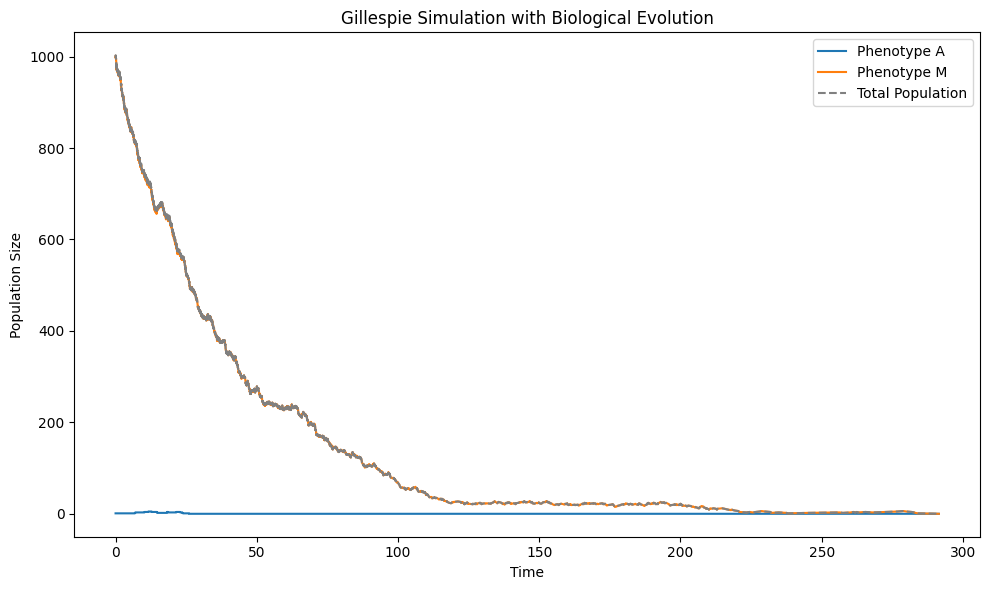

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 

def Biological_SingleRun(b_A, b_M, d=0.1, mu=1e-4, K=1e4, T_max=1e3, init_pop_size=1000):
    #　This function simulates the population dynamics of two phenotypes A and M under biological evolution using the Gillespie algorithm.
    #　b_A  is the birth rate of phenotype A, 
    #　b_M  is the birth rate of phenotype M
    #　d    is the death rate (common for both phenotypes)
    #　mu   is the mutation rate (probability of changing phenotype at birth)
    #　K    is the environmental carrying capacity
    #　T_max is the maximum simulation time 
    

    #Set initial condition
    N_A = 1
    N_M = init_pop_size-N_A

    t = 0
    times = [t]
    pop_A = [N_A]
    pop_M = [N_M]
    pop_total = [N_A + N_M]


    # Gillespie algotithm loop
    # The Gillespie algorithm is a stochastic simulation algorithm used to model the time evolution of systems
    # with discrete events, such as birth and death processes in populations.
    while t < T_max and (N_A + N_M) > 0:
        total_N = N_A + N_M
        birth_A = b_A * N_A * (1 - total_N / K)
        birth_M = b_M * N_M * (1 - total_N / K)
        death_A = d * N_A
        death_M = d * N_M

        rates = [birth_A, birth_M, death_A, death_M]
        rate_sum = sum(rates)

        if rate_sum == 0:
            break
        # waiting time until the next event
        dt = np.random.exponential(1 / rate_sum)
        t += dt

        # event selection
        r = np.random.uniform(0, rate_sum)
        if r < rates[0]:  # birth of A
            if np.random.rand() < mu:
                N_M += 1  # mutation to M
            else:
                N_A += 1
        elif r < rates[0] + rates[1]:  # birth of M
            if np.random.rand() < mu:
                N_A += 1  # mutation to A
            else:
                N_M += 1
        elif r < rates[0] + rates[1] + rates[2]:  # death of A
            N_A -= 1
        else:  # death of M  
            N_M -= 1

        # save the current state
        times.append(t)
        pop_A.append(N_A)
        pop_M.append(N_M)
        pop_total.append(N_A + N_M)
    return pd.DataFrame({'time': times, 'pop_A': pop_A, 'pop_M': pop_M, 'pop_total': pop_total })


# 結果のプロット
df = Biological_SingleRun(b_A=0.12, b_M=0.08)
plt.figure(figsize=(10, 6))
plt.plot(df['time'], df['pop_A'], label='Phenotype A')
plt.plot(df['time'], df['pop_M'], label='Phenotype M')
plt.plot(df['time'], df['pop_total'], label='Total Population', linestyle='--', color='gray')
plt.xlabel('Time')
plt.ylabel('Population Size')
plt.title('Gillespie Simulation with Biological Evolution')
plt.legend()
plt.tight_layout()
plt.show()


In [1]:
def SocialLearning(X, Y, learning_bias=0, parm=1):
    # This function simulates the social learning process between two individuals X and Y.
    # learning_bias: 0: content bias, 1: conformity bias, and 2: anticonformity bias
    # parm: strength of social learning bias; default value gives the unbiased case
    
    # Eitehr X or Y can be zero, which means no individuals of that type are present.
    if X==0:
        return 0
    elif Y==0:
        return 1
    
    if learning_bias == 0:  # content bias
        return parm*X/(X+Y)
    elif learning_bias == 1:  # conformity bias
        return (X**parm)/(X**parm + Y**parm)
    elif learning_bias == 2:  # anticonformity bias
        return (X**(-parm))/(X**(-parm) + Y**(-parm))
    else:
        raise ValueError("Invalid learning bias value. Use 0, 1, or 2.")    

def Cultural_SingleRun(b_A, b_M, d=0.1, s_max=0.1, K=1e4, T_max=1e3, init_pop_size=1000, learning_bias=0, parm=1.1, innovation=0):
    #　This function simulates the population dynamics of two phenotypes A and M under biological evolution using the Gillespie algorithm.
    #　b_A  is the birth rate of phenotype A, given by delta + d
    #　b_M  is the birth rate of phenotype M, given by delta - d
    #　d    is the death rate (common for both phenotypes)
    #　s_max   is the maximum social_learning rate
    #　K    is the environmental carrying capacity
    #　T_max is the maximum simulation time 
    #  learning_bias is the social bias 0: content bias, 1: conformity bias, and 2: anticonformity bias
    #  parm is the strength of social learning bias
    #  innovation is the rate of innovation (cultural evolution) from M to A or A to M
    
    

    #Set initial condition
    N_A = 1
    N_M = init_pop_size-N_A

    t = 0
    times = [t]
    pop_A = [N_A]
    pop_M = [N_M]
    pop_total = [N_A + N_M]


    # Gillespie algotithm loop
    # The Gillespie algorithm is a stochastic simulation algorithm used to model the time evolution of systems
    # with discrete events, such as birth and death processes in populations.
    while t < T_max and (N_A + N_M) > 0:
        total_N = N_A + N_M
        birth_M = (b_M * N_M + b_A * N_A) * (1 - total_N / K) # offpsrings' phenotype is always M
        death_A = d * N_A
        death_M = d * N_M
        if learning_bias == 0:  # content bias
            cul_evo_M_A = (s_max*SocialLearning(N_A, N_M, learning_bias, parm) + innovation)* N_M # type: ignore # cultural evolution from M to A
            cul_evo_A_M = (s_max*SocialLearning(N_M, N_A, learning_bias, 1/parm) + innovation) * N_A # cultural evolution from A to M
        else:
            cul_evo_M_A = (s_max*SocialLearning(N_A, N_M, learning_bias, parm) + innovation) * N_M # cultural evolution from M to A
            cul_evo_A_M = (s_max*SocialLearning(N_M, N_A, learning_bias, parm) + innovation) * N_A # cultural

        rates = [birth_M, death_A, death_M, cul_evo_M_A, cul_evo_A_M]
        rate_sum = sum(rates)

        if rate_sum == 0:
            break
        # waiting time until the next event
        dt = np.random.exponential(1 / rate_sum)
        t += dt

        # event selection
        r = np.random.uniform(0, rate_sum)
        if r < rates[0]:  # birth of M
            N_M += 1  # 
    
        elif r < rates[0] + rates[1]:  # death of A
            N_A -= 1  # mutation to A
    
        elif r < rates[0] + rates[1] + rates[2]:  # death of M
            N_M -= 1
        elif  r < rates[0] + rates[1] + rates[2]+ rates[3] :  # cultural evolution from M to A    
            N_M -= 1
            N_A += 1
        else:  # cultural evolution from A to M
            N_A -= 1
            N_M += 1

        # save the current state
        times.append(t)
        pop_A.append(N_A)
        pop_M.append(N_M)
        pop_total.append(N_A + N_M)
    return pd.DataFrame({'time': times, 'pop_A': pop_A, 'pop_M': pop_M, 'pop_total': pop_total })

# 結果のプロット
df = Cultural_SingleRun(b_A=0.12, b_M=0.08, s_max=0.2, learning_bias=2, parm=1.1, innovation=1e-4)
plt.figure(figsize=(10, 6))
plt.plot(df['time'], df['pop_A'], label='Phenotype A')
plt.plot(df['time'], df['pop_M'], label='Phenotype M')
plt.plot(df['time'], df['pop_total'], label='Total Population', linestyle='--', color='gray')
plt.xlabel('Time')
plt.ylabel('Population Size')
plt.xlim(0, 1000)
plt.title('Social learning simulation')
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'np' is not defined

# Model withouot evolution

In [159]:
def Baseline_Model(b_A=0.11, b_M=0.075, d=0.1, c =1e-3,  mu=0, iteration=1000,T_max=1e3, init_pop_size=1000, trajectory=False):
    # This function simulates the population dynamics of two phenotypes A and M under biological evolution using the Gillespie algorithm.
    # b_A  is the birth rate of phenotype A,
    # b_M  is the birth rate of phenotype M
    # iteration is the number of simulation runs to estimate the extinction probability
    # d    is the death rate (common for both phenotypes)
    # mu   is the mutation rate (probability of changing phenotype at birth)
    # K    is the environmental carrying capacity
    # T_max is the maximum simulation time

    extinction_count = 0
    fraction_A = []
    rescue_time = []
    if trajectory:
        all_records = []
    for i in range(iteration):
        # Set initial condition
        N_A = 0
        N_M = init_pop_size
        flag = 0
        t = 0
        times = [t]
        pop_A = [N_A]
        pop_M = [N_M]
        pop_total = [N_A + N_M]

        # Gillespie algorithm loop
        # The Gillespie algorithm is a stochastic simulation algorithm used to model the time evolution of systems
        # with discrete events, such as birth and death processes in populations.
        if trajectory:
                all_records.append({
                    "traj_id": i,           
                    "time": t,            
                     "pop_total": N_A+N_M })
        while t < T_max and (N_A + N_M) > 0:    
            total_N = N_A + N_M
            birth_A = b_A * N_A
            birth_M = b_M * N_M
            death_A = d * N_A
            death_M = d * N_M
            competition_A = c * N_A * total_N
            competition_M = c * N_M * total_N

            rates = [birth_A, birth_M, death_A, death_M, competition_A, competition_M]
            rate_sum = sum(rates)

            if rate_sum == 0:
                break
            # waiting time until the next event
            dt = np.random.exponential(1 / rate_sum)
            t += dt

            # event selection
            r = np.random.uniform(0, rate_sum)
            if r < rates[0]:  # birth of A
                if np.random.rand() < mu:
                    N_M += 1  # mutation to M
                else:
                    N_A += 1
            elif r < rates[0] + rates[1]:  # birth of M
                if np.random.rand() < mu:
                    N_A += 1  # mutation to A
                else:
                    N_M += 1
            elif r < rates[0] + rates[1] + rates[2]:  # natural death of A
                N_A -= 1
            elif r < rates[0] + rates[1] + rates[2] + rates[3]:  # natural death of M
                N_M -= 1
            elif r < rates[0] + rates[1] + rates[2] + rates[3] + rates[4]:  # competition death of A
                N_A -= 1
            else:  # competition death of M
                N_M -= 1
            if trajectory:
                all_records.append({
                    "traj_id": i,
                    "time": t,
                    "pop_total": N_A + N_M
                })

        if N_A + N_M == 0:
            extinction_count += 1
    if trajectory:
        df_traj = pd.DataFrame(all_records)
       #fig, ax = plt.subplots(figsize=(6, 4))
       # for traj_id, df_one in df_traj.groupby("traj_id"):
       #     ax.plot(
        #        df_one["time"],
        #       df_one["pop_total"],
        #       color="grey",
        #       alpha=0.01,      
        #        linewidth=0.5)
        #    ax.set_xlabel("Time")
        #    ax.set_ylabel("Population size")
        return extinction, df_traj
    else:
        return extinction_count
 # parameter lists   
iteration=1000
c_list  = [1e-4, 3e-4, 1e-3, 3e-3]
init_pop_size_list = [1e1, 1e2, 1e3]
param_product = product(c_list,    init_pop_size_list)
df_params = pd.DataFrame(param_product, columns=["c", "init_pop_size"])
for i in range(len(df_params)):
       
    c = df_params.loc[i, "c"]
    init_pop_size = int(df_params.loc[i, "init_pop_size"])
    if c==1e-4 and init_pop_size==1e3:
        extinction, df_traj= Baseline_Model(b_M=0.075, d=0.1, c=c, iteration=1000, T_max=1e3, init_pop_size=init_pop_size, trajectory=True)
    else:
        extinction = Baseline_Model(b_M=0.075, d=0.1, c=c, iteration=iteration, T_max=1e3, init_pop_size=init_pop_size, trajectory=False)
    df_params.loc[i, "extinction"] = extinction
    df_params.loc[i, "rescue"] = iteration-extinction
df_params.to_csv('BaselineModel.csv', index=False)
df_traj.to_csv('BaselineModel_Trajectories.csv', index=False)

       

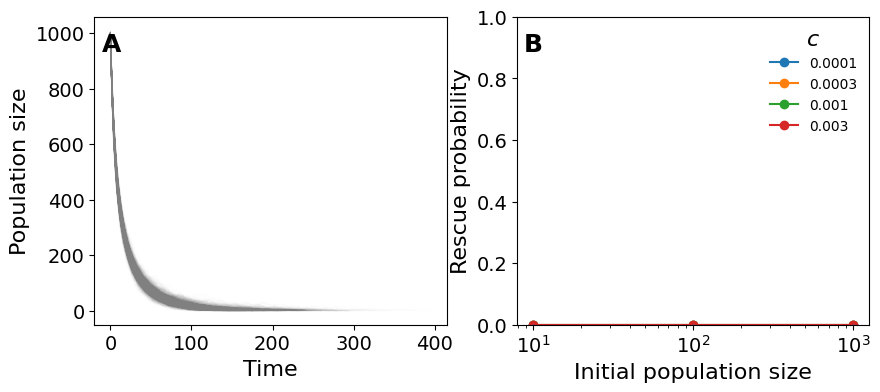

In [185]:
def beta_credible_interval(row, alpha=0.05):
    a = 1 + row["rescue"]
    b = 1 + row["extinction"]
    lower = beta.ppf(alpha / 2, a, b)
    upper = beta.ppf(1 - alpha / 2, a, b)
    return pd.Series({
        "rescue_prob": row["rescue"] / (row["rescue"] + row["extinction"]),
        "ci_lower": lower,
        "ci_upper": upper
    })

def scatter_with_ci(data, color, **kwargs):
    plt.scatter(
        data["b_A"],
        data["rescue_prob"],
        color=color,
        s=70,
        zorder=3
    )
    plt.vlines(
        data["b_A"],
        data["ci_lower"],
        data["ci_upper"],
        color=color,
        linewidth=1
    )
def format_mu(mu):   
    if mu == 0:        
        return r"$0$"    
    else:        
        return rf"$10^{{{int(np.log10(mu))}}}$"
    
df_base=pd.read_csv('BaselineModel.csv')
df_traj=pd.read_csv('BaselineModel_Trajectories.csv')
df_base[["rescue_prob", "ci_lower", "ci_upper"]] = df_base.apply(beta_credible_interval, axis=1)
df_base["c_label"] = df_base["c"].map(lambda x: f"{x:.6f}".rstrip("0").rstrip("."))
fig, axs = plt.subplot_mosaic(
    [["traj", "prob"]],          # 1行2列
    figsize=(10, 4),
    gridspec_kw={"width_ratios": [1, 1]}
)

ax_traj = axs["traj"]   # 左：trajectory
ax_prob = axs["prob"]   # 右：rescue probability
for traj_id, df_one in df_traj.groupby("traj_id"):
    ax_traj.plot(
        df_one["time"],
        df_one["pop_total"],
        color="grey",
        alpha=0.01,
        linewidth=0.8
    )

ax_traj.set_xlabel("Time", fontsize=16)
ax_traj.set_ylabel("Population size", fontsize=16)



for c_val, df_c in df_base.groupby("c"):
    label = f"{c_val:.6f}".rstrip("0").rstrip(".")

    # 中心値（線＋点）
    ax_prob.plot(
        df_c["init_pop_size"],
        df_c["rescue_prob"],
        marker="o",
        label=label
    )

    # 95% credible interval（上下端をそのまま描画）
    ax_prob.vlines(
        x=df_c["init_pop_size"],
        ymin=df_c["ci_lower"],
        ymax=df_c["ci_upper"],
        linewidth=1,
        alpha=0.9
    )
ax_prob.set_xscale("log")
ax_prob.set_xlabel("Initial population size", fontsize=16)
ax_prob.set_ylabel("Rescue probability", fontsize=16)
ax_prob.set_ylim(0, 1)
leg = ax_prob.legend(
    title="$c$",
    frameon=False,
    loc="upper right"
)
leg.get_title().set_fontsize(16)
for ax in axs.values(): 
    ax.tick_params(axis="both", which="major", labelsize=14)
panel_labels = string.ascii_uppercase  # 'A', 'B', 'C', ...


labels = {"traj": "A", "prob": "B"}

for key, label in labels.items():
    ax = axs[key]
    ax.text(
        0.02, 0.95, label,
        transform=ax.transAxes, 
        fontsize=18,
        fontweight="bold",
        va="top",
        ha="left"
    )

plt.savefig('Baseline_Model_Results.pdf', bbox_inches='tight')

# Model with biological evolution
Standing variance (i.e., the presence of a single adaptive mutant) is assumed

In [3]:
def Biological_MultipleRun(b_A, b_M=0.075, d=0.1, c =1e-3,  mu=1e-4, iteration=1000,T_max=1e3, init_pop_size=1000):
    #　This function simulates the population dynamics of two phenotypes A and M under biological evolution using the Gillespie algorithm.
    #　b_A  is the birth rate of phenotype A, 
    #　b_M  is the birth rate of phenotype M
    # iteration is the number of simulation runs to estiamte the extinction probability
    #　d    is the natural death rate (common for both phenotypes)
    #　mu   is the mutation rate (probability of changing phenotype at birth)
    #　c    is the death rate through the competition
    #　T_max is the maximum simulation time 
    
    extinction_count=0    
    fraction_A=[]
    rescue_time=[]
    for i in range(iteration):
        #Set initial condition
        N_A = 1
        N_M = init_pop_size-N_A
        flag=0
        t = 0
        times = [t]
        pop_A = [N_A]
        pop_M = [N_M]
        pop_total = [N_A + N_M]
        save_time=np.nan


        # Gillespie algotithm loop
        # The Gillespie algorithm is a stochastic simulation algorithm used to model the time evolution of systems
        # with discrete events, such as birth and death processes in populations.
        while t < T_max and (N_A + N_M) > 0:
            total_N = N_A + N_M
            birth_A = b_A * N_A 
            birth_M = b_M * N_M 
            death_A = d * N_A
            death_M = d * N_M
            competition_A = c * N_A* total_N
            competition_M = c * N_M * total_N

            rates = [birth_A, birth_M, death_A, death_M, competition_A, competition_M]
            rate_sum = sum(rates)

            if rate_sum == 0:
                break
            # waiting time until the next event
            dt = np.random.exponential(1 / rate_sum)
            t += dt

            # event selection
            r = np.random.uniform(0, rate_sum)
            if r < rates[0]:  # birth of A
                if np.random.rand() < mu:
                    N_M += 1  # mutation to M
                else:
                    N_A += 1
            elif r < rates[0] + rates[1]:  # birth of M
                if np.random.rand() < mu:
                    N_A += 1  # mutation to A
                else:
                    N_M += 1
            elif r < rates[0] + rates[1] + rates[2]:  # natural death of A
                N_A -= 1
            elif r < rates[0] + rates[1] + rates[2] + rates[3]:  # natural death of M
                N_M -= 1
            elif r < rates[0] + rates[1] + rates[2] + rates[3] + rates[4]:  # competition death of A
                N_A -= 1
            else:  # competition death of M
                N_M -= 1
            if N_A>(b_A - d) /c * 0.1 and flag==0:
                flag=1
                save_time=t

        if N_A+N_M==0:
             extinction_count+=1
        else:
             # save the final fraction of A in the population and the time to rescue (time until A reaches a certain threshold, e.g., 10% of the carrying capacity)
             fraction_A.append(N_A/(N_A+N_M))
        if flag==1:
             rescue_time.append(save_time)

    mean_fraction = np.mean(fraction_A) if fraction_A else 0
    mean_rescue_time = np.nanmean(rescue_time) if rescue_time else 0
    var_fraction = np.var(fraction_A) if fraction_A else 0
    var_rescue_time = np.nanvar(rescue_time) if rescue_time else 0
    return extinction_count, mean_fraction, mean_rescue_time, var_fraction, var_rescue_time
#Biological_MultipleRun(b_A=0.12, b_M=0.08, iteration=100, mu=1e-3, c=1e-4, T_max=1e3, init_pop_size=1000)


In [2]:
from itertools import product
def Biological_ParameterSweep(d=0.1, b_M=0.075, iteration=1000, T_max=1e3):

    # parameter lists
    b_A_list = [0.11, 0.12,  0.15, 0.2, 0.25, 0.3]  # d < b_A
    mu_list = [0, 1e-5, 1e-4, 1e-3]
    c_list  = [3e-4, 1e-4, 3e-3, 1e-3]
    init_pop_size_list = [1e1, 1e2, 1e3]
    param_product = product(b_A_list, mu_list,    c_list,    init_pop_size_list)
    df_params = pd.DataFrame(param_product, columns=["b_A", "mu", "c", "init_pop_size"])
    for i in range(len(df_params)):
        b_A = df_params.loc[i, "b_A"]
        mu = df_params.loc[i, "mu"]
        c = df_params.loc[i, "c"]
        init_pop_size = int(df_params.loc[i, "init_pop_size"])
        extinction, mean_fraction, mean_rescue_time, var_fraction, var_rescue_time = Biological_MultipleRun(b_A=b_A, b_M=b_M, d=0.1, c=c, mu=mu, iteration=iteration, T_max=T_max, init_pop_size=init_pop_size)
        df_params.loc[i, "extinction"] = extinction
        df_params.loc[i, "rescue"] = iteration-extinction
        df_params.loc[i, "mean_fraction"] = mean_fraction
        df_params.loc[i, "mean_rescue_time"] = mean_rescue_time
        df_params.loc[i, "var_fraction"] = var_fraction
        df_params.loc[i, "var_rescue_time"] = var_rescue_time
    return df_params

#df_bio=Biological_ParameterSweep(d=0.1, iteration=1000, T_max=1e3)
#df_bio.to_csv('Biological_evolutionary_rescue.csv', index=False)


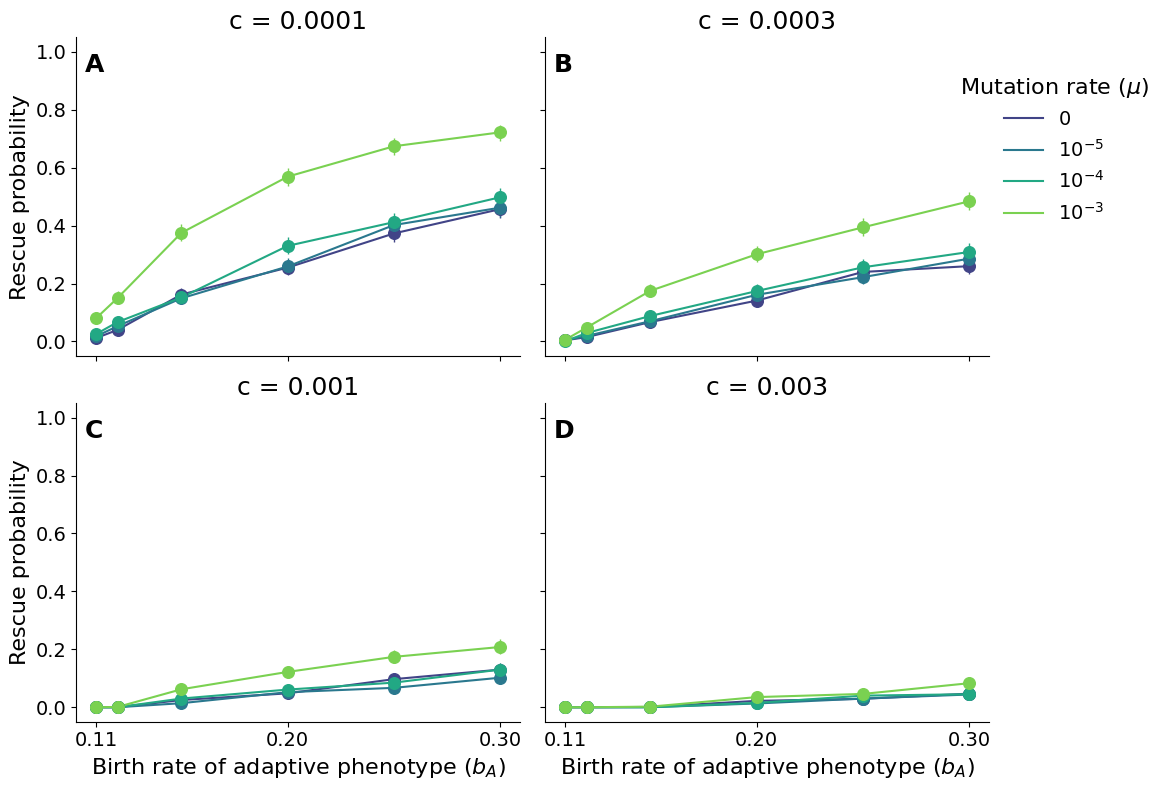

In [32]:
# Plot figures
import seaborn as sns
from scipy.stats import beta
import string


def beta_credible_interval(row, alpha=0.05):
    a = 1 + row["rescue"]
    b = 1 + row["extinction"]
    lower = beta.ppf(alpha / 2, a, b)
    upper = beta.ppf(1 - alpha / 2, a, b)
    return pd.Series({
        "rescue_prob": row["rescue"] / (row["rescue"] + row["extinction"]),
        "ci_lower": lower,
        "ci_upper": upper
    })

def scatter_with_ci(data, color, **kwargs):
    plt.scatter(
        data["b_A"],
        data["rescue_prob"],
        color=color,
        s=70,
        zorder=3
    )
    plt.vlines(
        data["b_A"],
        data["ci_lower"],
        data["ci_upper"],
        color=color,
        linewidth=1
    )
def format_mu(mu):   
    if mu == 0:        
        return r"$0$"    
    else:        
        return rf"$10^{{{int(np.log10(mu))}}}$"
df_bio=pd.read_csv('Biological_evolutionary_rescue.csv')
init_pop=1000
df_plot = df_bio[(df_bio["init_pop_size"] == init_pop)].copy()
df_plot[["rescue_prob","ci_lower", "ci_upper"]] = df_plot.apply(
    beta_credible_interval,
    axis=1
)
c_order = sorted(df_plot["c"].unique())
df_plot["mu_label"] = df_plot["mu"].apply(
    format_mu
)
g = sns.FacetGrid(
    df_plot,
    col="c",
    hue="mu_label",
    col_wrap=2,
    col_order=c_order,   
    height=4,
    aspect=1.1,
    palette="viridis",
    sharey=True
)

g.map_dataframe(
    sns.lineplot,
    x="b_A",
    y="rescue_prob"
)

g.map_dataframe(scatter_with_ci)
for ax in g.axes.flat:
    ax.tick_params(axis='both', which='major', labelsize=14)
g.set_axis_labels(r"Birth rate of adaptive phenotype ($b_A$)", "Rescue probability", fontsize=16)
g.set_titles(col_template="c = {col_name}", size=18)
g.set(ylim=(-0.05, 1.05))
g.add_legend(title="Mutation rate ($μ$)", prop={"size": 14})
g.legend.set_bbox_to_anchor((1.15, 0.8))
g.legend.set_frame_on(False)
g.legend.get_title().set_fontsize(16)
g.tight_layout(rect=[0, 0, 0.85, 1])
xticks = np.array([0.11, 0.2, 0.3])
for ax in g.axes.flat:
    ax.set_xticks(xticks)

panel_labels = string.ascii_uppercase  # 'A', 'B', 'C', ...

for ax, label in zip(g.axes.flat, panel_labels):
    ax.text(
        0.02, 0.95, label,
        transform=ax.transAxes,  
        fontsize=18,
        fontweight='bold',
        va='top',
        ha='left'
    )

plt.tight_layout()
fname=f'Biological_evolutionary_rescue_plot_init_pop_{init_pop}.pdf'
plt.savefig(fname, dpi=300, bbox_inches='tight')
plt.show()

# Model with cultural evolution

In [2]:
def SocialLearning(X, Y, learning_bias=0, parm=1):
    # This function simulates the social learning process between two individuals X and Y.
    # learning_bias: 0: content bias, 1: conformity bias, and 2: anticonformity bias
    # parm: strength of social learning bias; default value gives the unbiased case
    
    # Eitehr X or Y can be zero, which means that cultural evolution cannot change the phenotype
    if X==0:
        return 0
    elif Y==0:
        return 1
    
    if learning_bias == 0:  # content bias
        return (1+parm)*X/((1+parm)*X+Y)
    elif learning_bias == 1:  # conformity bias
        return (X**(1+parm))/(X**(1+parm) + Y**(1+parm))
    elif learning_bias == 2:  # anticonformity bias
        return (X**(-parm))/(X**(-parm) + Y**(-parm))
    else:
        raise ValueError("Invalid learning bias value. Use 0, 1, or 2.")    

def Cultural_MultipleRun(b_A, b_M=0.075, d=0.1, c =1e-3,  mu=1e-4, s=0.1, learning_bias=0, parm=1, iteration=1000,T_max=1e3, init_pop_size=1000):
    #　This function simulates the population dynamics of two phenotypes A and M under biological evolution using the Gillespie algorithm.
    #　b_A  is the birth rate of phenotype A, 
    #　b_M  is the birth rate of phenotype M
    # iteration is the number of simulation runs to estiamte the extinction probability
    #　d    is the natural death rate (common for both phenotypes)
    # c    is the death rate by competition common for both phenotypes)
    #　mu   is the innovation rate ( changing to the other phenotype through try-and-error
    #　s.   is the rate of of social learning
    #  learning_bias is the social bias 0: content bias, 1: conformity bias, and 2: anticonformity bias
    #  parm is the strength of social learning bias   
    #　T_max is the maximum simulation time 
    
    extinction_count=0    
    fraction_A=[]
    rescue_time=[]
    for i in range(iteration):
        #Set initial condition
        N_A = 1
        N_M = init_pop_size-N_A
        flag=0
        t = 0
        times = [t]
        pop_A = [N_A]
        pop_M = [N_M]
        pop_total = [N_A + N_M]
        save_time=np.nan


        # Gillespie algotithm loop
        # The Gillespie algorithm is a stochastic simulation algorithm used to model the time evolution of systems
        # with discrete events, such as birth and death processes in populations.
        while t < T_max and (N_A + N_M) > 0:
            total_N = N_A + N_M
            birth_tot = b_A * N_A + b_M * N_M 
            death_A = d * N_A
            death_M = d * N_M
            competition_A = c * N_A* total_N
            competition_M = c * N_M * total_N
            ind_learning_A = mu * N_A
            ind_learning_M = mu * N_M
            soc_learning_A = s * N_A
            soc_learning_M = s * N_M

            rates = [birth_tot, death_A, death_M, competition_A, competition_M,
                    ind_learning_A, ind_learning_M, soc_learning_A, soc_learning_M]
            rate_sum = sum(rates)

            if rate_sum == 0:
                break
            # waiting time until the next event
            dt = np.random.exponential(1 / rate_sum)
            t += dt

            # event selection
            # note that all newborn individuals are assumed M under the cultural evolution
            r = np.random.uniform(0, rate_sum)
            if r < rates[0]:  # birth of M from A or M 
                    N_M += 1
            elif r < rates[0] + rates[1]:  # natural death of A
                N_A -= 1
            elif r < rates[0] + rates[1] + rates[2]:  # natural death of M
                N_M -= 1
            elif r < rates[0] + rates[1] + rates[2] + rates[3]:  # competition death of A
                N_A -= 1
            elif r < rates[0] + rates[1] + rates[2] + rates[3] + rates[4]:  # competition death of M
                N_M -= 1
            elif r < rates[0] + rates[1] + rates[2] + rates[3] + rates[4] + rates[5]:  # individual learning from A to M
                N_A -= 1
                N_M += 1
            elif r < rates[0] + rates[1] + rates[2] + rates[3] + rates[4] + rates[5] + rates[6]:  # individual learning from M to A
                N_M -= 1
                N_A += 1
            # write about the social learning from here
            #-----------------------
            elif r < rates[0] + rates[1] + rates[2] + rates[3] + rates[4] + rates[5] + rates[6] + rates[7]:  # social learning of A
                if SocialLearning(N_A, N_M, learning_bias, parm) < np.random.rand():
                    # individual with phenotype A changes to M through social learning
                    N_A -= 1
                    N_M += 1
                #otherwise, the individual with A socially learns A; nothing happens
            else:  # social learning of M
                if SocialLearning(N_A, N_M, learning_bias, parm) > np.random.rand():
                    # individual with phenotype M changes to A through social learning
                    N_M -= 1
                    N_A += 1
                 #otherwise, the individual with M socially learns M; nothing happens   
            if N_A>(b_A - d) /c * 0.1 and flag==0:
                flag=1
                save_time=t

        if N_A+N_M==0:
             extinction_count+=1
        else:
             # save the final fraction of A in the population and the time to rescue (time until A reaches a certain threshold, e.g., 10% of the carrying capacity)
             fraction_A.append(N_A/(N_A+N_M))
        if flag==1:
             rescue_time.append(save_time)

    mean_fraction = np.mean(fraction_A) if fraction_A else 0
    mean_rescue_time = np.nanmean(rescue_time) if rescue_time else 0
    var_fraction = np.var(fraction_A) if fraction_A else 0
    var_rescue_time = np.nanvar(rescue_time) if rescue_time else 0
    return extinction_count, mean_fraction, mean_rescue_time, var_fraction, var_rescue_time
#df_test=Cultural_MultipleRun(b_A=0.2, b_M=0.075, d=0.1, s=0,   learning_bias=0, parm=1, mu=1, c=1e-3, iteration=10,T_max=1e3, init_pop_size=1000)

## Individual learning alone

In [10]:
# Individaul learning alone

from itertools import product
def Cultural_Individual_ParameterSweep(d=0.1, b_M=0.075, iteration=1000, T_max=1e3):

    # parameter lists
    b_A_list = [0.11, 0.12,  0.15, 0.2, 0.25, 0.3]  # d < b_A
    mu_list = [0, 1e-5, 1e-4, 1e-3, 1e-1] # individual learning rate
    c_list  = [3e-4, 1e-4, 3e-3, 1e-3]
    init_pop_size_list = [1e1, 1e2, 1e3]
    param_product = product(b_A_list, mu_list,    c_list,    init_pop_size_list)
    df_params = pd.DataFrame(param_product, columns=["b_A", "mu", "c", "init_pop_size"])
    for i in range(len(df_params)):
        b_A = df_params.loc[i, "b_A"]
        mu = df_params.loc[i, "mu"]
        c = df_params.loc[i, "c"]
        init_pop_size = int(df_params.loc[i, "init_pop_size"])
        extinction, mean_fraction, mean_rescue_time, var_fraction, var_rescue_time = Cultural_MultipleRun(b_A=b_A, b_M=b_M, d=0.1, c=c,
                                                                                                          s=0, learning_bias=0, parm=0,
                                                                                                          mu=mu, iteration=iteration, T_max=T_max, init_pop_size=init_pop_size)
        df_params.loc[i, "extinction"] = extinction
        df_params.loc[i, "rescue"] = iteration-extinction
        df_params.loc[i, "mean_fraction"] = mean_fraction
        df_params.loc[i, "mean_rescue_time"] = mean_rescue_time
        df_params.loc[i, "var_fraction"] = var_fraction
        df_params.loc[i, "var_rescue_time"] = var_rescue_time
    return df_params

df_cul_ind=Cultural_Individual_ParameterSweep(d=0.1, iteration=1000, T_max=1e3)
df_cul_ind.to_csv('Cultural_evolutionary_rescue_individual.csv', index=False)

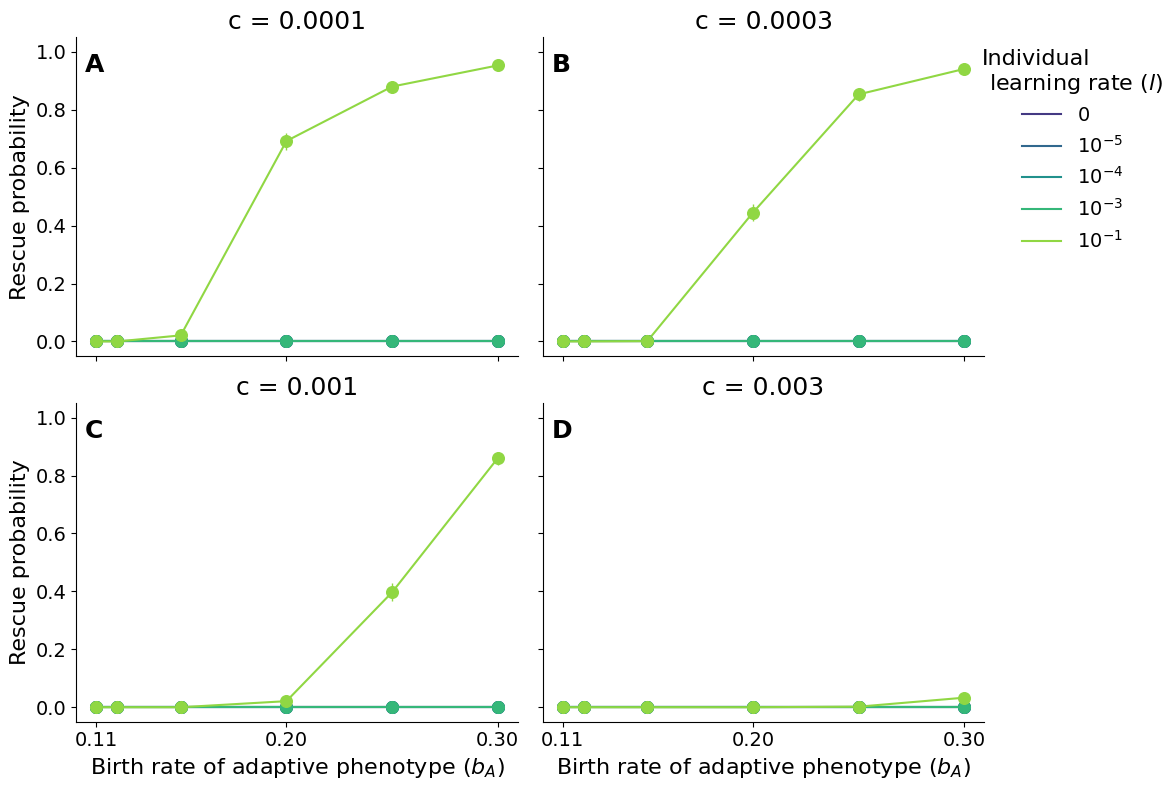

In [29]:
# Plot figures
import seaborn as sns
from scipy.stats import beta
import string


def beta_credible_interval(row, alpha=0.05):
    a = 1 + row["rescue"]
    b = 1 + row["extinction"]
    lower = beta.ppf(alpha / 2, a, b)
    upper = beta.ppf(1 - alpha / 2, a, b)
    return pd.Series({
        "rescue_prob": row["rescue"] / (row["rescue"] + row["extinction"]),
        "ci_lower": lower,
        "ci_upper": upper
    })

def scatter_with_ci(data, color, **kwargs):
    plt.scatter(
        data["b_A"],
        data["rescue_prob"],
        color=color,
        s=70,
        zorder=3
    )
    plt.vlines(
        data["b_A"],
        data["ci_lower"],
        data["ci_upper"],
        color=color,
        linewidth=1
    )
def format_mu(mu):   
    if mu == 0:        
        return r"$0$"    
    else:        
        return rf"$10^{{{int(np.log10(mu))}}}$"
df_cul_ind=pd.read_csv('Cultural_evolutionary_rescue_individual.csv')
init_pop=10
df_plot = df_cul_ind[(df_cul_ind["init_pop_size"] == init_pop)].copy()
df_plot[["rescue_prob","ci_lower", "ci_upper"]] = df_plot.apply(
    beta_credible_interval,
    axis=1
)
c_order = sorted(df_plot["c"].unique())
df_plot["mu_label"] = df_plot["mu"].apply(
    format_mu
)
g = sns.FacetGrid(
    df_plot,
    col="c",
    hue="mu_label",
    col_wrap=2,
    col_order=c_order,   
    height=4,
    aspect=1.1,
    palette="viridis",
    sharey=True
)

g.map_dataframe(
    sns.lineplot,
    x="b_A",
    y="rescue_prob"
)

g.map_dataframe(scatter_with_ci)
for ax in g.axes.flat:
    ax.tick_params(axis='both', which='major', labelsize=14)
g.set_axis_labels(r"Birth rate of adaptive phenotype ($b_A$)", "Rescue probability", fontsize=16)
g.set_titles(col_template="c = {col_name}", size=18)
g.set(ylim=(-0.05, 1.05))
g.add_legend(title="Individual\n learning rate ($l$)", prop={"size": 14})
g.legend.set_bbox_to_anchor((1.17, 0.8))
g.legend.set_frame_on(False)
g.legend.get_title().set_fontsize(16)
g.tight_layout(rect=[0, 0, 0.85, 1])
xticks = np.array([0.11, 0.2, 0.3])
for ax in g.axes.flat:
    ax.set_xticks(xticks)

panel_labels = string.ascii_uppercase  # 'A', 'B', 'C', ...

for ax, label in zip(g.axes.flat, panel_labels):
    ax.text(
        0.02, 0.95, label,
        transform=ax.transAxes,  
        fontsize=18,
        fontweight='bold',
        va='top',
        ha='left'
    )

plt.tight_layout()
fname=f'Cultural_evolutionary_rescue_individual_plot_init_pop_{init_pop}.pdf'
plt.savefig(fname, dpi=300, bbox_inches='tight')
plt.show()

## Including social learning

In [6]:
from itertools import product
def Cultural_Social_ParameterSweep(learning_bias=0, d=0.1, b_M=0.075, iteration=1000, T_max=1e3):

    # parameter lists
    b_A_list = [0.11, 0.12,  0.15, 0.2, 0.25, 0.3]  # d < b_A
    mu_list = [0, 1e-5, 1e-4, 1e-3, 1e-1] # individual learning rate
    c_list  = [3e-4, 1e-4, 3e-3, 1e-3]
    s_list = [1e-5, 1e-3, 1e-1, 1]
    init_pop_size_list = [1e1, 1e2, 1e3]
    if learning_bias == 0:
        # content bias
        parm_list=[-0.5, -0.2, -0.1, 0, 0.1, 0.2, 0.5, 1]
    elif learning_bias == 1:
        # conformity bias
        parm_list=[0.1, 0.5, 1, 1.5, 2]
    elif learning_bias == 2:
        # anticonformity bias
        parm_list = [1.1, 1.5, 2, 2.5, 3]
    param_product = product(b_A_list, mu_list,    c_list,    s_list, parm_list, init_pop_size_list)
    df_params = pd.DataFrame(param_product, columns=["b_A", "mu", "c", 
                                                     "s", "parm", "init_pop_size"])
    for i in range(len(df_params)):
        if i%1000 ==0:
            print(i)
        b_A = df_params.loc[i, "b_A"]
        mu = df_params.loc[i, "mu"]
        s = df_params.loc[i, "s"]
        c = df_params.loc[i, "c"]
        parm = df_params.loc[i, "parm"] 
        init_pop_size = int(df_params.loc[i, "init_pop_size"])
        extinction, mean_fraction, mean_rescue_time, var_fraction, var_rescue_time = Cultural_MultipleRun(b_A=b_A, b_M=b_M, d=d, c=c,
                                                                                                          s=s, learning_bias=learning_bias, parm=parm,
                                                                                                          mu=mu, iteration=iteration, T_max=T_max, 
                                                                                                          init_pop_size=init_pop_size)
        df_params.loc[i, "extinction"] = extinction
        df_params.loc[i, "rescue"] = iteration-extinction
        df_params.loc[i, "mean_fraction"] = mean_fraction
        df_params.loc[i, "mean_rescue_time"] = mean_rescue_time
        df_params.loc[i, "var_fraction"] = var_fraction
        df_params.loc[i, "var_rescue_time"] = var_rescue_time
    return df_params
    
#print("Content bias simulations")
df_cul_content=Cultural_Social_ParameterSweep(learning_bias = 0, d=0.1, iteration=2, T_max=1e1)
df_cul_content.to_csv('TEST_Cultural_evolutionary_rescue_content.csv', index=False)

#print("Conformity bias simulations")
df_cul_conformity=Cultural_Social_ParameterSweep(learning_bias =1, d=0.1, iteration=2, T_max=1e1)
df_cul_conformity.to_csv('TEST_Cultural_evolutionary_rescue_conformity.csv', index=False)

#print("Anticonformity bias simulations")
df_cul_anticonformity=Cultural_Social_ParameterSweep(learning_bias=2, d=0.1, iteration=2, T_max=1e1)
df_cul_anticonformity.to_csv('TEST_Cultural_evolutionary_rescue_anticonformity.csv', index=False)

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
0
1000
2000
3000
4000
5000
6000
7000
0
1000
2000
3000
4000
5000
6000
7000


NameError: name 'df_cul_anticonformity' is not defined

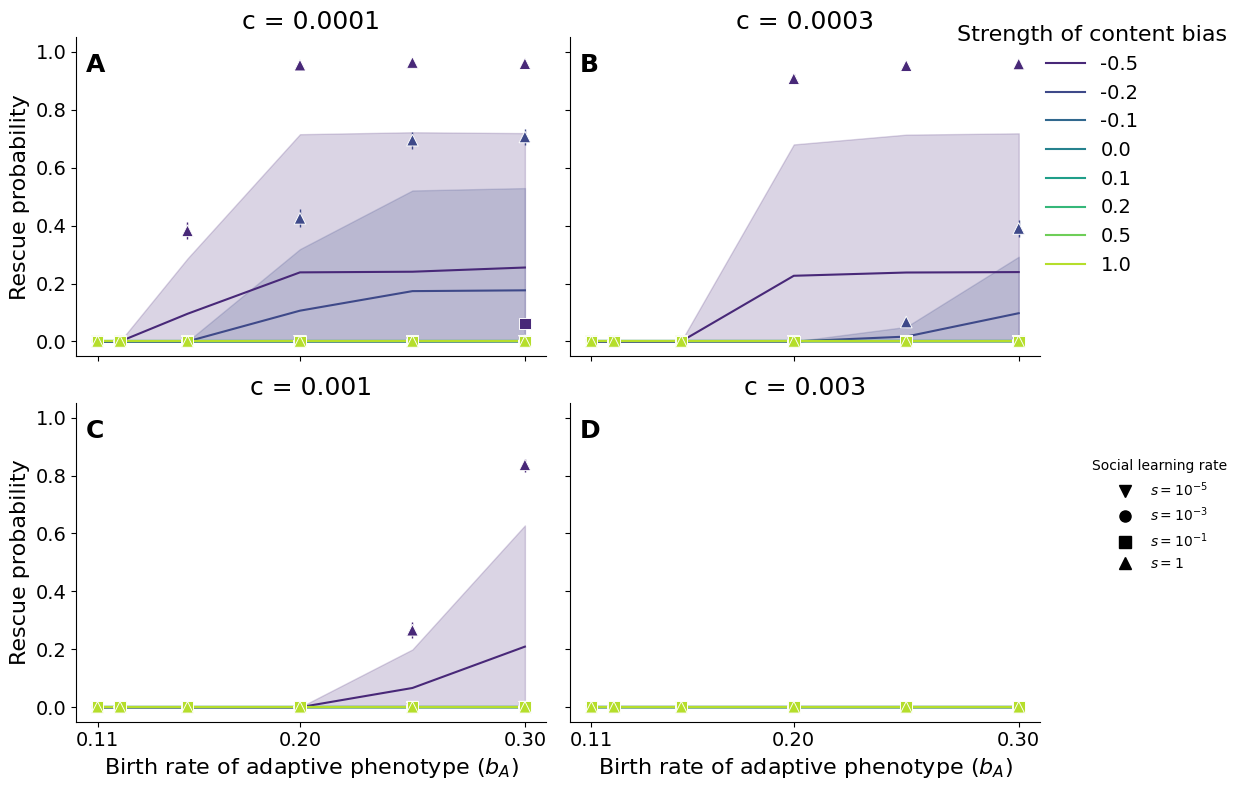

In [34]:
# Plot figures
import seaborn as sns
from scipy.stats import beta
import string
from matplotlib.lines import Line2D


def beta_credible_interval(row, alpha=0.05):
    a = 1 + row["rescue"]
    b = 1 + row["extinction"]
    lower = beta.ppf(alpha / 2, a, b)
    upper = beta.ppf(1 - alpha / 2, a, b)
    return pd.Series({
        "rescue_prob": row["rescue"] / (row["rescue"] + row["extinction"]),
        "ci_lower": lower,
        "ci_upper": upper
    })

def scatter_with_ci(data, color, **kwargs):
    sns.scatterplot(
        data=data,
        x="b_A",
        y="rescue_prob",
        style="s",
        markers={0.00001: "v", 0.001: "o", 0.1: "s", 1: "^"},
        color=color,
        s=70,
        zorder=3,
        legend=False  
    )
    plt.vlines(
        data["b_A"],
        data["ci_lower"],
        data["ci_upper"],
        color=color,
        linewidth=1
    )
def format_mu(mu):   
    if mu == 0:        
        return r"$0$"    
    else:        
        return rf"$10^{{{int(np.log10(mu))}}}$"


df_cul_content=pd.read_csv('Cultural_evolutionary_rescue_content.csv')
init_pop=1000

df_plot = df_cul_content[    (df_cul_content["init_pop_size"] == init_pop) 
&    (df_cul_content["mu"] == 0)].copy()

df_plot[["rescue_prob","ci_lower", "ci_upper"]] = df_plot.apply(
    beta_credible_interval,
    axis=1
)
c_order = sorted(df_plot["c"].unique())
df_plot["mu_label"] = df_plot["mu"].apply(
    format_mu
)

g = sns.FacetGrid(
    df_plot,
    col="c",
    hue="parm",
    col_wrap=2,
    col_order=c_order,   
    height=4,
    aspect=1.1,
    palette="viridis",
    sharey=True
)

g.map_dataframe(
    sns.lineplot,
    x="b_A",
    y="rescue_prob"
)

g.map_dataframe(scatter_with_ci)
for ax in g.axes.flat:
    ax.tick_params(axis='both', which='major', labelsize=14)
g.set_axis_labels(r"Birth rate of adaptive phenotype ($b_A$)", "Rescue probability", fontsize=16)
g.set_titles(col_template="c = {col_name}", size=18)
g.set(ylim=(-0.05, 1.05))
g.add_legend(title="Strength of content bias", prop={"size": 14})
g.legend.set_bbox_to_anchor((1.17, 0.8))
g.legend.set_frame_on(False)
g.legend.get_title().set_fontsize(16)
g.tight_layout(rect=[0, 0, 0.85, 1])
xticks = np.array([0.11, 0.2, 0.3])
for ax in g.axes.flat:
    ax.set_xticks(xticks)


shape_legend = [
    Line2D([0], [0], marker="v", linestyle="None", color="black",
           markersize=8, label=r"$s = 10^{-5}$"),
    Line2D([0], [0], marker="o", linestyle="None", color="black",
           markersize=8, label=r"$s = 10^{-3}$"),
    Line2D([0], [0], marker="s", linestyle="None", color="black",
           markersize=8, label=r"$s = 10^{-1}$"),
    Line2D([0], [0], marker="^", linestyle="None", color="black",
           markersize=8, label=r"$s = 1$")
]

g.fig.legend(
    handles=shape_legend,
    title="Social learning rate",
    loc="center right",
    bbox_to_anchor=(1.17, 0.35),
    frameon=False
)

panel_labels = string.ascii_uppercase  # 'A', 'B', 'C', ...

for ax, label in zip(g.axes.flat, panel_labels):
    ax.text(
        0.02, 0.95, label,
        transform=ax.transAxes,  
        fontsize=18,
        fontweight='bold',
        va='top',
        ha='left'
    )

plt.tight_layout()
#fname=f'Cultural_evolutionary_rescue_individual_plot_init_pop_{init_pop}.pdf'
#plt.savefig(fname, dpi=300, bbox_inches='tight')
plt.show()

In [5]:
import sys
print(sys.executable)
!{sys.executable} -m pip install joblib

/Users/shotashibasaki/myenv/bin/python
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)

[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: /Users/shotashibasaki/myenv/bin/python -m pip install --upgrade pip


In [6]:
import joblib
joblib.__version__

'1.5.3'